# 02 - Modelado multietiqueta

## Resumen amplio

Este notebook entrena y compara modelos para sugerir articulos candidatos del CEDH a partir del texto de hechos. La salida es un vector de diez articulos, no una clase unica.

El modelo principal es **TF-IDF + Regresion Logistica One-vs-Rest con umbrales por etiqueta**. Se elige porque es reproducible, fuerte para texto largo y explicable por pesos de terminos. Se compara con un baseline frecuente, SVM lineal y una red neuronal ligera **TF-IDF + SVD + MLP**. El MLP aporta una comparacion no lineal ejecutable sin GPU ni dependencias pesadas.

Los umbrales se ajustan en `validation`; `test` queda reservado para evaluacion final. Esta decision evita leakage y mejora el trato de etiquetas raras.

## Indice

1. Carga de matrices reales `X` e `Y`.
2. Formulacion One-vs-Rest.
3. Entrenamiento y comparacion.
4. Interpretacion de metricas.
5. Ejemplos reales de prediccion.
6. Figura de pipeline y umbrales.
7. Artefactos guardados.


![Esquema especifico generado con Image Gen](artifacts/figures/generated/notebook_02_modeling.png)

**Lectura del esquema.** La imagen resume el modelado: TF-IDF como representacion comun, comparacion de LogReg OVR, SVM y SVD+MLP, ajuste de umbrales y metricas multietiqueta. La imagen es conceptual; las cifras y conclusiones se calculan en las celdas del notebook con datos reales.


In [1]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import project_utils as pu
warnings.filterwarnings('ignore')
pu.configure(); sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 180)


## 1. Datos de modelado

Se reconstruyen las particiones desde SQLite. El vectorizador se ajusta solo con train.


In [2]:
pu.materialize_database(force=False)
frames = pu.train_validation_test_frames()
for split, df in frames.items():
    print(split, df.shape)
    display(df[['case_id','split','n_tokens'] + pu.ARTICLE_CODES].head(3))


train (9000, 17)


,case_id,split,n_tokens,2,3,5,6,8,9,10,11,14,P1-1
0,ecthr_task_b_train_000000,train,7014,0,0,0,0,1,0,0,0,0,0
1,ecthr_task_b_train_000001,train,2788,0,0,0,1,0,0,0,0,1,1
2,ecthr_task_b_train_000002,train,1380,0,0,0,1,0,0,0,0,0,0


validation (1000, 17)


,case_id,split,n_tokens,2,3,5,6,8,9,10,11,14,P1-1
0,ecthr_task_b_validation_000000,validation,310,0,0,0,0,1,0,0,0,0,0
1,ecthr_task_b_validation_000001,validation,1260,0,1,0,0,0,0,0,0,0,0
2,ecthr_task_b_validation_000002,validation,2116,0,1,0,1,0,0,0,0,0,0


test (1000, 17)


,case_id,split,n_tokens,2,3,5,6,8,9,10,11,14,P1-1
0,ecthr_task_b_test_000000,test,4774,0,0,0,0,0,0,1,0,0,0
1,ecthr_task_b_test_000001,test,1073,0,0,0,0,1,0,0,0,0,0
2,ecthr_task_b_test_000002,test,302,0,0,0,1,0,0,0,0,0,0


## 2. Formulacion One-vs-Rest

Para cada articulo se entrena un clasificador binario: presente o ausente. Esto permite scores y umbrales separados por etiqueta. Aunque ignora dependencias explicitas entre articulos, facilita interpretabilidad y auditoria.


## 2.1 Pipeline completo: entradas, transformaciones y salidas

El pipeline de modelado se puede leer como una cadena de objetos concretos, no como una caja negra:

| Paso | Entrada | Transformacion | Salida | Por que se hace |
|---|---|---|---|---|
| Carga desde SQLite | `cases.text_full` y `case_labels` | Union con la matriz multietiqueta `Y` | DataFrames por split | Mantiene separados texto, etiquetas y protocolo experimental. |
| Vectorizacion TF-IDF | Lista de textos reales | Unigramas y bigramas ponderados por frecuencia inversa | `X_train`, `X_val`, `X_test` dispersas | Representa texto largo sin truncar y permite interpretar terminos. |
| Logistic Regression OVR | `X_train`, `Y_train` | 10 clasificadores binarios independientes | Probabilidad por articulo | Da scores calibrables y coeficientes auditables. |
| SVM lineal OVR | `X_train`, `Y_train` | 10 hiperplanos de margen maximo | Etiquetas binarias | Comparador fuerte para alta dimensionalidad TF-IDF. |
| SVD + MLP | `X_train`, `Y_train` | Reduccion densa + red neuronal de una capa | Scores por articulo | Comparacion no lineal  |
| Umbrales | Scores de validation | Busqueda de mejor F1 por articulo | `tau_j` por articulo | Evita usar un 0.5 global que puede perjudicar etiquetas raras. |
| Evaluacion | `Y_split`, `Y_pred` | Macro-F1, micro-F1, Hamming loss | Tablas CSV y predicciones SQLite | Permite comparar modelos y auditar errores caso a caso. |

La entrada final del sistema es siempre texto real de un caso. La salida final del modelo principal es un vector de diez decisiones binarias, una por articulo, junto con diez scores continuos que permiten ordenar confianza y explicar errores.


In [3]:
label_support = frames['train'][pu.ARTICLE_CODES].sum().rename('train_positives').rename_axis('article_code').reset_index()
label_support['validation_positives'] = frames['validation'][pu.ARTICLE_CODES].sum().values
label_support['test_positives'] = frames['test'][pu.ARTICLE_CODES].sum().values
display(label_support)


,article_code,train_positives,validation_positives,test_positives
0,2,623,75,76
1,3,1740,236,234
2,5,1623,219,196
3,6,5437,394,394
4,8,1056,153,188
5,9,81,9,11
6,10,441,64,106
7,11,162,39,43
8,14,444,34,32
9,P1-1,1558,168,155


## 3. Entrenamiento y comparacion

La funcion compartida entrena o reutiliza artefactos compatibles. Modelos:

- baseline de articulo mas frecuente;
- regresion logistica con umbral 0.5;
- SVM lineal;
- regresion logistica con umbrales ajustados;
- red neuronal ligera SVD+MLP con umbrales ajustados.

Todos usan ejemplos reales del dataset y se evaluan sobre `validation` y `test`.


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
import joblib

MODEL_PATHS = {
    'vectorizer': pu.MODELS / 'notebook_tfidf_vectorizer.joblib',
    'logreg': pu.MODELS / 'notebook_logreg_ovr.joblib',
    'svm': pu.MODELS / 'notebook_svm_ovr.joblib',
    'mlp': pu.MODELS / 'notebook_svd_mlp.joblib',
    'thresholds': pu.MODELS / 'notebook_thresholds.json',
}


def load_split_arrays(frames, label_columns):
    """Convierte los DataFrames por split en arrays de entrenamiento.

    Entrada:
        frames: diccionario con DataFrames `train`, `validation` y `test`.
        label_columns: lista de articulos usados como columnas objetivo.

    Salida:
        Diccionario por split con tres piezas:
        - `case_ids`: identificadores de casos, usados para guardar predicciones.
        - `texts`: textos completos `text_full`, entrada del vectorizador.
        - `y`: matriz binaria real `(n_casos, n_articulos)`.
    """
    arrays = {}
    for split, df in frames.items():
        arrays[split] = {
            'case_ids': df['case_id'].tolist(),
            'texts': df['text_full'].tolist(),
            'y': df[label_columns].to_numpy(dtype=int),
        }
    return arrays


def build_or_load_vectorizer(train_texts, all_texts, retrain=False):
    """Ajusta o carga el vectorizador TF-IDF y transforma todos los splits.

    Entrada:
        train_texts: textos de entrenamiento. Solo aqui se aprende vocabulario.
        all_texts: diccionario con textos de todos los splits.
        retrain: si es `True`, ignora artefactos previos y reentrena.

    Salida:
        `(vectorizer, matrices)` donde:
        - `vectorizer` transforma texto en una matriz dispersa TF-IDF.
        - `matrices[split]` es `X_split`, matriz `(n_casos, n_features)`.

    Por que se hace asi:
        TF-IDF es determinista, soporta documentos largos y permite recuperar
        nombres de terminos para XAI. El vocabulario no se aprende con
        validation ni test para evitar leakage.
    """
    if MODEL_PATHS['vectorizer'].exists() and not retrain:
        vectorizer = joblib.load(MODEL_PATHS['vectorizer'])
    else:
        vectorizer = TfidfVectorizer(
            ngram_range=(1, 2), min_df=2, max_df=0.95, max_features=60000,
            sublinear_tf=True, strip_accents='unicode', lowercase=True, dtype=np.float32
        )
        vectorizer.fit(train_texts)
        joblib.dump(vectorizer, MODEL_PATHS['vectorizer'])
    matrices = {split: vectorizer.transform(texts) for split, texts in all_texts.items()}
    return vectorizer, matrices


def train_or_load_linear_models(x_train, y_train, retrain=False):
    """Entrena o carga los dos modelos lineales One-vs-Rest.

    Entrada:
        x_train: matriz TF-IDF de entrenamiento `(n_casos, n_features)`.
        y_train: matriz binaria real `(n_casos, n_articulos)`.
        retrain: si es `True`, fuerza reentrenamiento.

    Salida:
        `(logreg, svm)`:
        - `logreg`: 10 regresiones logisticas, una por articulo. Produce
          probabilidades y por eso permite ajustar umbrales.
        - `svm`: 10 SVM lineales. No produce probabilidades calibradas, pero
          es un comparador fuerte en espacios TF-IDF dispersos.

    Como entrena:
        `OneVsRestClassifier` descompone el problema multietiqueta en 10
        problemas binarios independientes: articulo j presente frente a ausente.
    """
    if MODEL_PATHS['logreg'].exists() and not retrain:
        logreg = joblib.load(MODEL_PATHS['logreg'])
    else:
        logreg = OneVsRestClassifier(LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced', random_state=pu.SEED))
        logreg.fit(x_train, y_train)
        joblib.dump(logreg, MODEL_PATHS['logreg'])

    if MODEL_PATHS['svm'].exists() and not retrain:
        svm = joblib.load(MODEL_PATHS['svm'])
    else:
        svm = OneVsRestClassifier(LinearSVC(class_weight='balanced', random_state=pu.SEED, max_iter=5000))
        svm.fit(x_train, y_train)
        joblib.dump(svm, MODEL_PATHS['svm'])
    return logreg, svm


def train_or_load_mlp(x_train, y_train, retrain=False):
    """Entrena o carga el modelo neuronal comparativo SVD+MLP.

    Entrada:
        x_train: matriz TF-IDF dispersa de entrenamiento.
        y_train: matriz binaria de articulos reales.
        retrain: si es `True`, fuerza reentrenamiento.

    Salida:
        Diccionario con tres objetos:
        - `svd`: reduce TF-IDF a 256 componentes densos.
        - `scaler`: normaliza esos componentes para el MLP.
        - `mlp`: red neuronal de una capa oculta que aprende interacciones no
          lineales entre componentes.

    Por que no usamos un transformer aqui:
        El objetivo es tener una comparacion neuronal ejecutable directamente en
        el notebook con CPU y dependencias ligeras. Un transformer juridico seria
        mas pesado, requeriria mas tiempo y probablemente GPU.
    """
    if MODEL_PATHS['mlp'].exists() and not retrain:
        return joblib.load(MODEL_PATHS['mlp'])
    svd = TruncatedSVD(n_components=256, random_state=pu.SEED)
    scaler = StandardScaler()
    z_train = scaler.fit_transform(svd.fit_transform(x_train))
    mlp = MLPClassifier(
        hidden_layer_sizes=(128,), activation='relu', alpha=1e-4,
        learning_rate_init=1e-3, max_iter=45, early_stopping=True,
        n_iter_no_change=5, batch_size=128, random_state=pu.SEED
    )
    mlp.fit(z_train, y_train)
    bundle = {'svd': svd, 'scaler': scaler, 'mlp': mlp}
    joblib.dump(bundle, MODEL_PATHS['mlp'])
    return bundle


def score_mlp(bundle, x_matrix):
    """Calcula scores por articulo para el modelo SVD+MLP.

    Entrada:
        bundle: diccionario devuelto por `train_or_load_mlp`.
        x_matrix: matriz TF-IDF del split que queremos evaluar.

    Salida:
        Matriz `(n_casos, n_articulos)` con scores de clase positiva.
    """
    z = bundle['scaler'].transform(bundle['svd'].transform(x_matrix))
    return pu.as_probability_matrix(bundle['mlp'].predict_proba(z))


def store_main_predictions(arrays, matrices, logreg, thresholds, metrics_rows):
    """Guarda predicciones del modelo principal para auditoria posterior.

    Entrada:
        arrays: textos, ids y etiquetas por split.
        matrices: matrices TF-IDF por split.
        logreg: modelo principal entrenado.
        thresholds: umbrales por articulo ajustados en validation.
        metrics_rows: metricas agregadas que describen la ejecucion.

    Salida:
        No devuelve nada. Inserta en SQLite una fila de experimento y una fila
        de prediccion por caso. El notebook 04 lee estas predicciones para XAI,
        shift y analisis de errores.
    """
    all_case_ids, all_true, all_pred, all_scores = [], [], [], []
    for split in pu.SPLIT_ORDER:
        scores = pu.as_probability_matrix(logreg.predict_proba(matrices[split]))
        pred = (scores >= thresholds).astype(int)
        all_case_ids.extend(arrays[split]['case_ids'])
        all_true.append(arrays[split]['y'])
        all_pred.append(pred)
        all_scores.append(scores)
    pu.save_run_and_predictions(
        run_id='notebook_threshold_tuned',
        model_name='tfidf_logreg_threshold_tuned',
        config={
            'representation': 'TF-IDF unigramas+bigramas, max_features=60000',
            'classifier': 'OneVsRest LogisticRegression(class_weight=balanced)',
            'thresholds': {code: float(value) for code, value in zip(pu.ARTICLE_CODES, thresholds)},
        },
        metrics=metrics_rows,
        case_ids=all_case_ids,
        y_true=np.vstack(all_true),
        y_pred=np.vstack(all_pred),
        scores=np.vstack(all_scores),
    )

RETRAIN_MODELS = False
arrays = load_split_arrays(frames, pu.ARTICLE_CODES)
vectorizer, matrices = build_or_load_vectorizer(
    arrays['train']['texts'],
    {split: arrays[split]['texts'] for split in pu.SPLIT_ORDER},
    retrain=RETRAIN_MODELS,
)
logreg, svm = train_or_load_linear_models(matrices['train'], arrays['train']['y'], retrain=RETRAIN_MODELS)
mlp_bundle = train_or_load_mlp(matrices['train'], arrays['train']['y'], retrain=RETRAIN_MODELS)

logreg_scores = {split: pu.as_probability_matrix(logreg.predict_proba(matrices[split])) for split in pu.SPLIT_ORDER}
thresholds = pu.tune_thresholds(arrays['validation']['y'], logreg_scores['validation'])
pu.save_json(MODEL_PATHS['thresholds'], {'thresholds': {code: float(value) for code, value in zip(pu.ARTICLE_CODES, thresholds)}})

most_frequent = int(np.argmax(arrays['train']['y'].sum(axis=0)))
rows = []
for split in ['validation', 'test']:
    baseline = np.zeros_like(arrays[split]['y'])
    baseline[:, most_frequent] = 1
    rows.append(pu.metric_table(arrays[split]['y'], baseline, split, 'baseline_most_frequent_label'))
    rows.append(pu.metric_table(arrays[split]['y'], (logreg_scores[split] >= 0.5).astype(int), split, 'tfidf_logreg_0.5'))
    rows.append(pu.metric_table(arrays[split]['y'], svm.predict(matrices[split]), split, 'tfidf_linear_svm'))
    rows.append(pu.metric_table(arrays[split]['y'], (logreg_scores[split] >= thresholds).astype(int), split, 'tfidf_logreg_threshold_tuned'))

mlp_scores = {split: score_mlp(mlp_bundle, matrices[split]) for split in ['validation', 'test']}
mlp_thresholds = pu.tune_thresholds(arrays['validation']['y'], mlp_scores['validation'])
for split in ['validation', 'test']:
    rows.append(pu.metric_table(arrays[split]['y'], (mlp_scores[split] >= mlp_thresholds).astype(int), split, 'tfidf_svd_mlp_threshold_tuned'))

comparison = pd.DataFrame(rows)
comparison.to_csv(pu.METRICS / 'classification_model_comparison.csv', index=False)
paper = pd.concat([
    pd.DataFrame([
        pu.metric_table(arrays['train']['y'], (logreg_scores['train'] >= thresholds).astype(int), 'train', 'tfidf_logreg_threshold_tuned'),
        pu.metric_table(arrays['validation']['y'], (logreg_scores['validation'] >= thresholds).astype(int), 'validation', 'tfidf_logreg_threshold_tuned'),
        pu.metric_table(arrays['test']['y'], (logreg_scores['test'] >= thresholds).astype(int), 'test', 'tfidf_logreg_threshold_tuned'),
    ]),
    comparison[comparison['model'].isin(['tfidf_linear_svm', 'tfidf_svd_mlp_threshold_tuned'])]
], ignore_index=True)
paper.to_csv(pu.METRICS / 'paper_classification_table.csv', index=False)
store_main_predictions(arrays, matrices, logreg, thresholds, paper.to_dict(orient='records'))

thresholds = pd.DataFrame({'article_code': pu.ARTICLE_CODES, 'threshold': thresholds})
display(comparison.sort_values(['split', 'macro_f1'], ascending=[True, False]))
display(thresholds)
print('Artefactos guardados:')
for name, path in MODEL_PATHS.items():
    print(f'- {name}: {path}')


,model,split,n_cases,macro_f1,micro_f1,hamming_loss
6,tfidf_linear_svm,test,1000,0.749354,0.786677,0.0570
9,tfidf_svd_mlp_threshold_tuned,test,1000,0.728547,0.769989,0.0653
5,tfidf_logreg_0.5,test,1000,0.714014,0.738337,0.0774
7,tfidf_logreg_threshold_tuned,test,1000,0.713807,0.751799,0.0690
4,baseline_most_frequent_label,test,1000,0.056528,0.323614,0.1647
3,tfidf_logreg_threshold_tuned,validation,1000,0.739720,0.774359,0.0616
8,tfidf_svd_mlp_threshold_tuned,validation,1000,0.735855,0.782115,0.0614
2,tfidf_linear_svm,validation,1000,0.718870,0.789751,0.0558
1,tfidf_logreg_0.5,validation,1000,0.717259,0.758431,0.0702
0,baseline_most_frequent_label,validation,1000,0.056528,0.329569,0.1603


,article_code,threshold
0,2,0.65
1,3,0.65
2,5,0.60
3,6,0.45
4,8,0.60
5,9,0.40
6,10,0.60
7,11,0.50
8,14,0.55
9,P1-1,0.55


Artefactos guardados:
- vectorizer: C:\Users\jordi\Documents\UNI\proyecto-aprendizaje-avanzado\artifacts\models\notebook_tfidf_vectorizer.joblib
- logreg: C:\Users\jordi\Documents\UNI\proyecto-aprendizaje-avanzado\artifacts\models\notebook_logreg_ovr.joblib
- svm: C:\Users\jordi\Documents\UNI\proyecto-aprendizaje-avanzado\artifacts\models\notebook_svm_ovr.joblib
- mlp: C:\Users\jordi\Documents\UNI\proyecto-aprendizaje-avanzado\artifacts\models\notebook_svd_mlp.joblib
- thresholds: C:\Users\jordi\Documents\UNI\proyecto-aprendizaje-avanzado\artifacts\models\notebook_thresholds.json


## Lectura de los resultados de entrenamiento

La comparacion no debe leerse como una carrera por una sola metrica. El baseline de articulo frecuente sirve para comprobar que el problema no se resuelve prediciendo siempre el articulo 6. La regresion logistica con umbral 0.5 muestra el comportamiento sin calibracion por etiqueta. La SVM lineal suele mejorar porque el margen funciona bien en espacios TF-IDF dispersos. El modelo `SVD+MLP` aporta una frontera no lineal: primero resume TF-IDF en componentes densos y despues aprende combinaciones no lineales.

El modelo principal del proyecto sigue siendo `tfidf_logreg_threshold_tuned` porque sus pesos se pueden auditar en el notebook 04. La SVM y el MLP son comparadores fuertes para discutir rendimiento, pero son menos directos de explicar localmente con coeficientes de palabras.


In [5]:
val_best = comparison[comparison['split'] == 'validation'].sort_values('macro_f1', ascending=False).iloc[0]
test_best = comparison[comparison['split'] == 'test'].sort_values('macro_f1', ascending=False).iloc[0]
main_test = comparison[(comparison['split'] == 'test') & (comparison['model'] == 'tfidf_logreg_threshold_tuned')].iloc[0]
baseline_test = comparison[(comparison['split'] == 'test') & (comparison['model'] == 'baseline_most_frequent_label')].iloc[0]
mlp_test = comparison[(comparison['split'] == 'test') & (comparison['model'] == 'tfidf_svd_mlp_threshold_tuned')].iloc[0]


## 3.1 Esquema visual: de texto a matrices X/Y y entrada al modelo

![Esquema X/Y y vectorizador TF-IDF](artifacts/figures/generated/notebook_02_xy_matrix_flow.png)

**Lectura del esquema.** Los textos reales entran al vectorizador TF-IDF, que construye la matriz `X`: filas = casos, columnas = terminos/bigramas, valores = pesos TF-IDF. En paralelo, las etiquetas reales forman la matriz `Y`: filas = los mismos casos, columnas = articulos, valores = 0/1. El modelo recibe `X` como entrada y aprende a aproximar `Y`; despues produce scores por articulo que se convierten en predicciones mediante umbrales.


## 4. Interpretacion de metricas

`macro_f1` penaliza fallar etiquetas escasas; `micro_f1` resume rendimiento global; `hamming_loss` mide decisiones articulo-caso incorrectas. En issue spotting juridico hay que mirar las tres porque falsos negativos y falsos positivos tienen costes distintos.


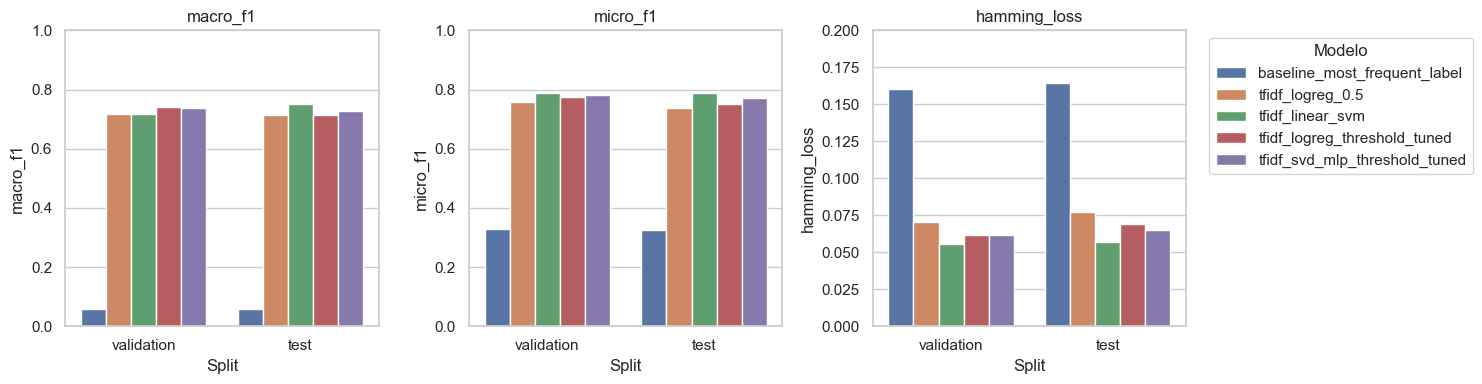

In [6]:
fig, axes = plt.subplots(1,3,figsize=(15,4))
for ax, metric in zip(axes, ['macro_f1','micro_f1','hamming_loss']):
    sns.barplot(data=comparison,x='split',y=metric,hue='model',ax=ax)
    ax.set_title(metric); ax.set_xlabel('Split')
    ax.set_ylim(0, max(0.2, comparison[metric].max()*1.15) if metric=='hamming_loss' else 1)
axes[0].legend_.remove(); axes[1].legend_.remove(); axes[2].legend(title='Modelo', bbox_to_anchor=(1.05,1), loc='upper left')
fig.tight_layout(); fig.savefig(pu.FIGURES/'model_comparison_metrics.png', dpi=180); plt.show()


## 5. Ejemplos reales de prediccion

Se leen predicciones guardadas en SQLite. La tabla muestra etiquetas verdaderas, predichas y score maximo para casos reales de test.


In [7]:
pred = pu.load_predictions('notebook_threshold_tuned')
def decode(row, field):
    """Convierte un vector binario de articulos en una lista legible.

    Entrada:
        row: fila de predicciones con `y_true` o `y_pred`.
        field: nombre del campo que contiene el vector binario.

    Salida:
        Cadena con codigos de articulos activos, o `(ninguno)` si no hay.
    """
    return ', '.join([code for code, value in zip(pu.ARTICLE_CODES, row[field]) if value]) or '(ninguno)'
sample = pred[pred['split']=='test'].head(8).copy()
sample['true_articles'] = sample.apply(lambda r: decode(r,'y_true'), axis=1)
sample['pred_articles'] = sample.apply(lambda r: decode(r,'y_pred'), axis=1)
sample['max_score'] = sample['scores'].map(lambda xs: max(xs) if xs else np.nan)
display(sample[['case_id','true_articles','pred_articles','max_score']])
display(pd.DataFrame([pu.summarize_case(sample.iloc[0]['case_id'], max_chars=1000)]))


,case_id,true_articles,pred_articles,max_score
0,ecthr_task_b_test_000000,10,"8, 10",0.949734
1,ecthr_task_b_test_000001,8,6,0.607172
2,ecthr_task_b_test_000002,6,6,0.624944
3,ecthr_task_b_test_000003,6,6,0.790289
4,ecthr_task_b_test_000004,"3, 6",3,0.965156
5,ecthr_task_b_test_000005,3,"3, 8",0.967893
6,ecthr_task_b_test_000006,6,6,0.564444
7,ecthr_task_b_test_000007,3,3,0.984210


,case_id,task,split,year,n_paragraphs,n_tokens,excerpt,article_codes
0,ecthr_task_b_test_000000,ecthr_task_b,test,None,37,4774,"5. The applicant is a journalist for DN.no, a Norwegian Internet-based version of the newspaper Dagens Næringsliv (“DN”), published by the company DN Nye Medier AS. 6. On 23...",10


## 6. Figuras de resultados y umbrales

La figura final ya no dibuja un pipeline decorativo. Resume informacion que se interpreta directamente: rendimiento por modelo, perdida Hamming y umbrales aprendidos por articulo. Los umbrales son relevantes porque convierten scores continuos en decisiones multietiqueta; un articulo con umbral bajo no es "mas importante", sino que en validacion necesito una frontera mas permisiva para maximizar F1 de esa etiqueta.


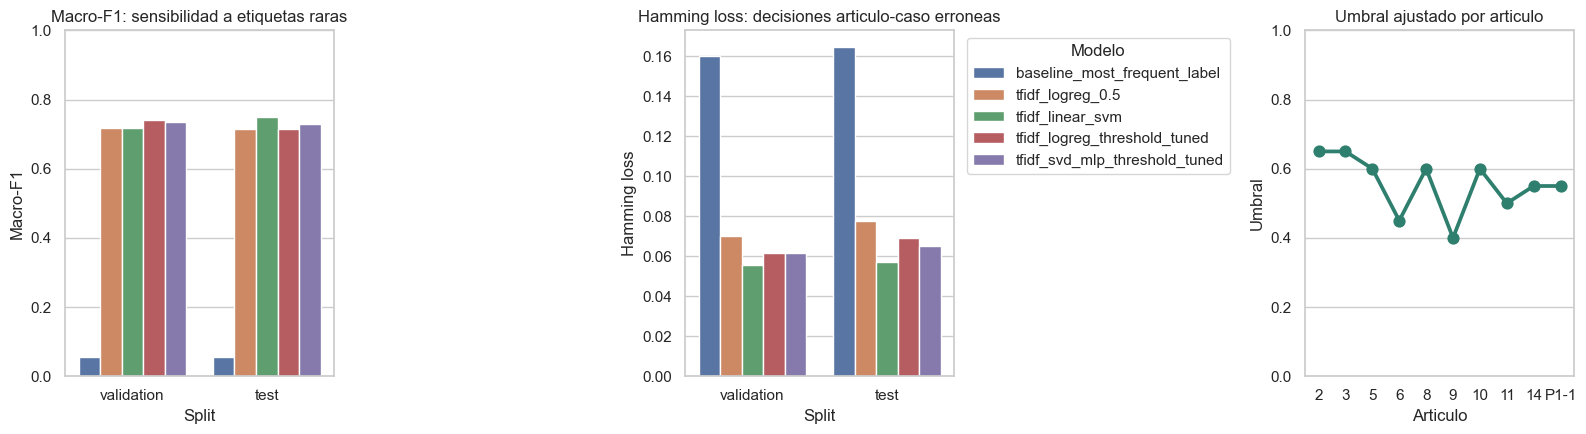

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
plot_df = comparison[comparison['split'].isin(['validation', 'test'])].copy()

sns.barplot(data=plot_df, x='split', y='macro_f1', hue='model', ax=axes[0])
axes[0].set_title('Macro-F1: sensibilidad a etiquetas raras')
axes[0].set_ylim(0, 1)
axes[0].set_xlabel('Split')
axes[0].set_ylabel('Macro-F1')

sns.barplot(data=plot_df, x='split', y='hamming_loss', hue='model', ax=axes[1])
axes[1].set_title('Hamming loss: decisiones articulo-caso erroneas')
axes[1].set_xlabel('Split')
axes[1].set_ylabel('Hamming loss')

sns.pointplot(data=thresholds, x='article_code', y='threshold', ax=axes[2], color='#2f7f6f')
axes[2].set_title('Umbral ajustado por articulo')
axes[2].set_ylim(0, 1)
axes[2].set_xlabel('Articulo')
axes[2].set_ylabel('Umbral')
axes[2].tick_params(axis='x', rotation=0)

axes[0].legend_.remove()
axes[1].legend(title='Modelo', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
fig.savefig(pu.FIGURES / 'fig04_modeling_and_thresholds.png', dpi=180)
plt.show()


## 7. Resultado del notebook

Quedan modelos en `artifacts/models/`, tablas `classification_model_comparison.csv` y `paper_classification_table.csv`, y predicciones por caso en SQLite para el notebook 04.
